In [1]:
from sklearn.model_selection import train_test_split

from Pipeline.Algorithm.ArtificialBeeColonyElmCVEnsemble import ArtificialBeeColonyElmCVEnsemble
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Methodology.EvaluationMatrix import EvaluationMatrix
from Pipeline.Global.Plotting import Plotting

In [2]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_raw_data_path()
gallstone_dataset.cross_validate_test()

In [3]:
all_train_curves = []
all_val_curves = []
all_test_scores = []
for idx in range(gallstone_dataset.splits):
    x_train , y_train , x_test , y_test = gallstone_dataset.fold_split[idx]
    x_tr , x_val , y_tr , y_val = train_test_split(x_train, y_train,
                                                test_size= GlobalSetting.test_set_size,
                                                random_state=GlobalSetting.data_split_seed,
                                                stratify=gallstone_dataset.y_train)

    abc_model = ArtificialBeeColonyElmCVEnsemble(
        feature_size        = x_tr.shape[1],
        hidden_size         = GlobalSetting.abc_trace_h_size ,
        activation_function = GlobalSetting.sigmoid,
        regularization_lambda= GlobalSetting.abc_trace_lambda,
        fitness_function    = GlobalSetting.evaluation_function,
        random_state        = GlobalSetting.abc_trace_seed,
        solution_size       = GlobalSetting.abc_trace_s_size,
        trial_limit         = GlobalSetting.abc_trace_t_size,
        max_iteration       = GlobalSetting.abc_trace_m_size
    )
    abc_model.employed_bee_apply_algo3()
    abc_model.onlooker_bee_apply_algo2()
    abc_model.apply_validation_dataset(x_val, y_val)
    abc_model.fit(x_tr, y_tr ,cv_folds= 10)
    val_fitness_curve = abc_model.val_fitness_curve
    best_fitness_curve = abc_model.convergence_curve

    y_pred = abc_model.predict(x_test = x_test)
    evaluation_result = EvaluationMatrix(y_true =y_test, y_pred = y_pred)
    test_score = evaluation_result.get_mcc()
    metric_to_track = GlobalSetting.evaluation_function
    final_test_score = evaluation_result.get_all_metrics()[metric_to_track]

    all_train_curves.append(best_fitness_curve)
    all_val_curves.append(val_fitness_curve)
    all_test_scores.append(test_score)



Seed 40  | Iteration 1000 complete | Duration: 1.1937s | Scout Triggers: 1 | Best Fitness: 0.790643 | Val Fitness: 0.747025

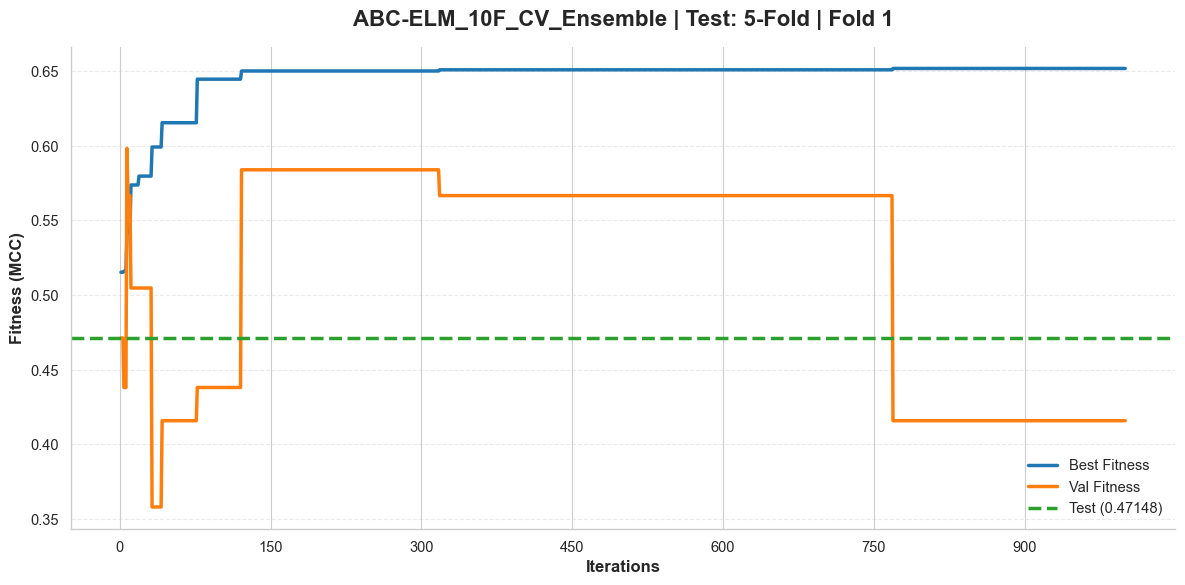

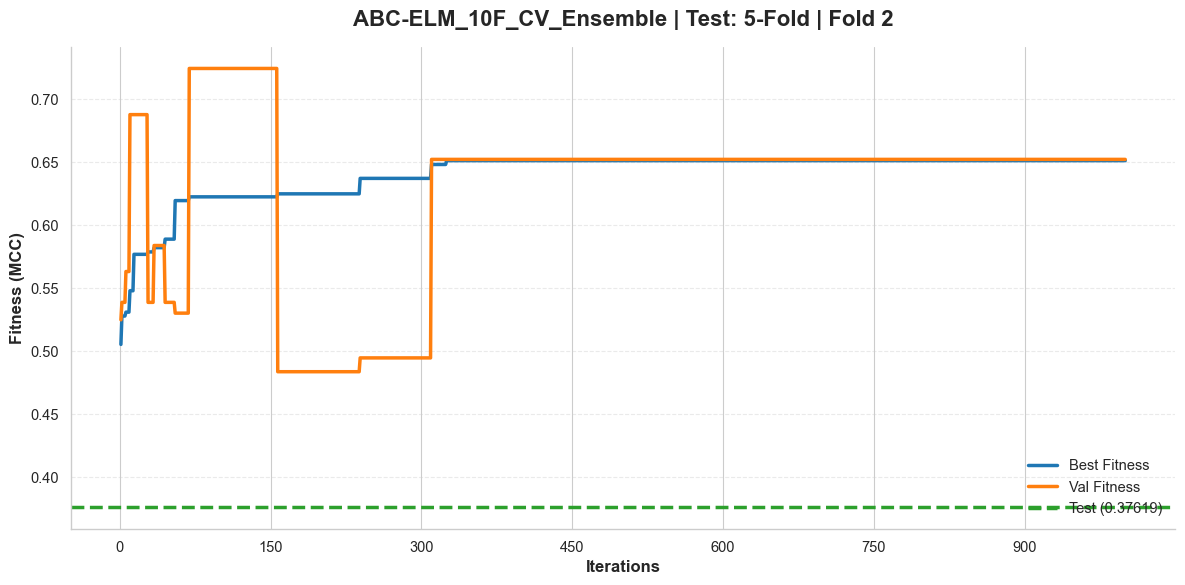

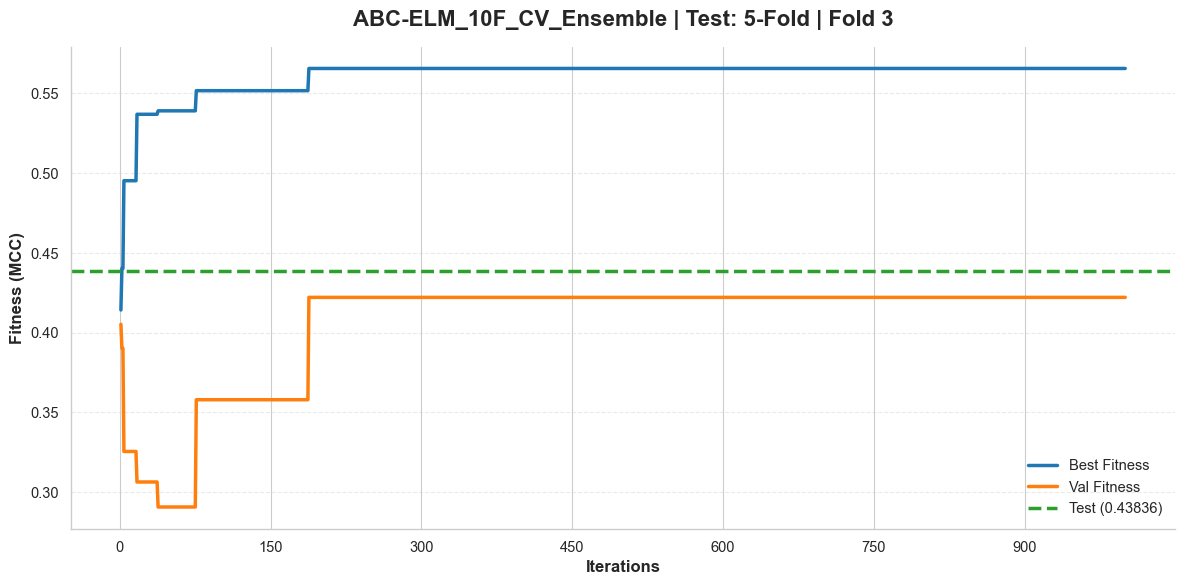

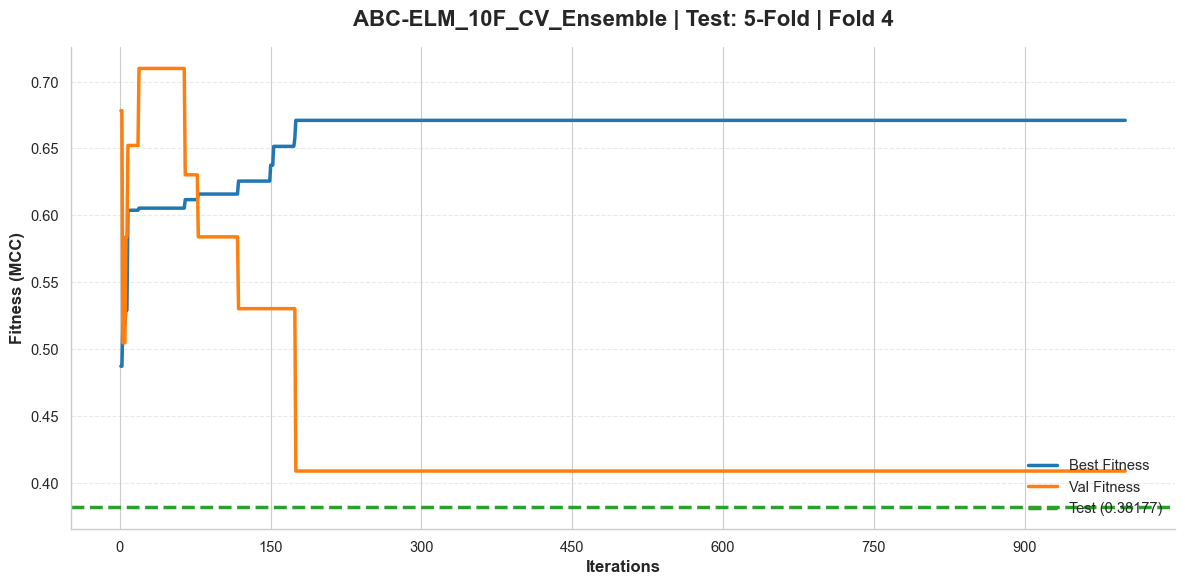

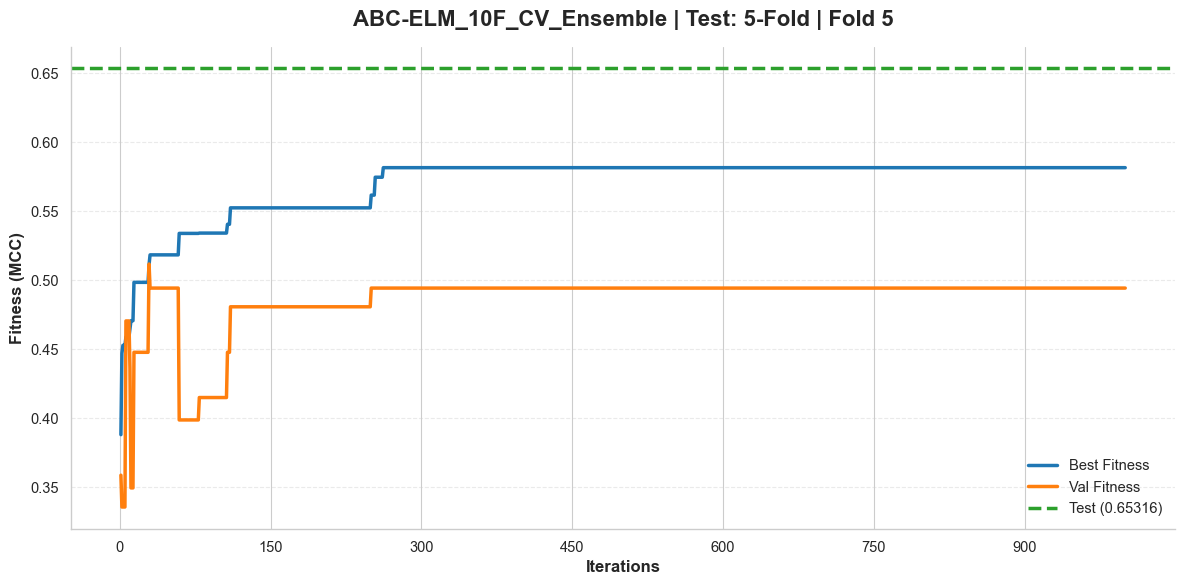

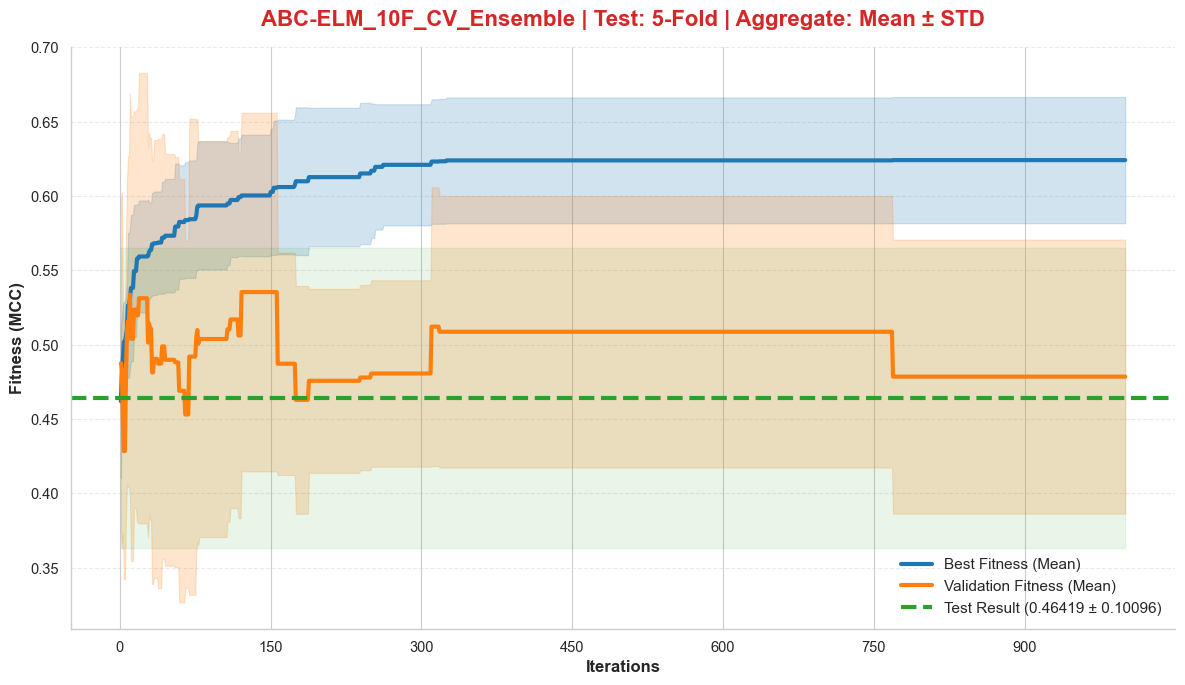

In [4]:
Plotting.plot_cv_grid(
    all_train_curves=all_train_curves,
    all_val_curves=all_val_curves,
    all_test_scores=all_test_scores,
    experiment_name=f"ABC-ELM_10F_CV_Ensemble | Test: {gallstone_dataset.splits}-Fold",
    fitness_metric=GlobalSetting.evaluation_function,
    is_final_record=False
)